In [ ]:
from pathlib import Path
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import sys
import torch

%load_ext autoreload
%autoreload 2

NB   = Path.cwd()
ROOT = NB.parent
SRC  = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from data_pipeline.config import CLEANED

RUN_DIR = Path(ROOT / "models/gae_run1")
CKPT = RUN_DIR / "best.pt"
CONF = RUN_DIR / "config.json"
RESULTS = RUN_DIR / "results.json"  # created by train_gae when save_outdir set
RUN_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# --- 1) Load panel exported from 02_simulator ---
panel = pd.read_csv(CLEANED / "hedging_panel_spx.csv", parse_dates=["date"])
panel = panel.sort_values("date").reset_index(drop=True)

print("Panel window:", panel["date"].min(), "→", panel["date"].max())
print("Columns:", list(panel.columns)[:12], "...")

Panel window: 2005-01-21 00:00:00 → 2023-08-31 00:00:00
Columns: ['date', 'close_spy', 'vix', 'rate_10y', 'hvol_10d', 'hvol_14d', 'hvol_30d', 'hvol_60d', 'hvol_91d', 'hvol_122d', 'hvol_152d', 'hvol_182d'] ...


In [3]:
from rl_agent.train_ac_gae import PolicyValueNet
from rl_agent.experiment import build_envs, deterministic_rewards
from rl_agent.trainer import evaluate_env

cfg = json.loads(CONF.read_text())
envs = build_envs(
    panel=panel,  # reuse your processed panel from earlier notebooks
    features=cfg["features"],
    train_end=cfg["train_end"],
    valid_end=cfg["valid_end"],
    window=cfg["window"],
    txn_cost_bps=cfg["txn_cost_bps"],
    pos_limit=cfg["pos_limit"],
    reward_scale=1e4,
)
env_tr, env_va, env_te = envs["env_tr"], envs["env_va"], envs["env_te"]


In [4]:
obs = env_tr.reset()
print("obs.shape:", getattr(obs, "shape", None), "len(flat):", np.asarray(obs).reshape(-1).shape)

obs.shape: (30, 8) len(flat): (240,)


In [5]:
from rl_agent.train_ac_gae import PolicyValueNet, make_obs_fixer

n_features = len(cfg["features"])
to_fixed = make_obs_fixer(cfg["window"], n_features)

net = PolicyValueNet(input_dim=env_tr.reset().size, hidden=cfg["hidden"])
net.load_state_dict(torch.load(CKPT, map_location="cpu"))
net.obs_fix = to_fixed
net.pos_limit = float(cfg["pos_limit"])

metrics = {
    "train": evaluate_env(env_tr, net, deterministic=True),
    "valid": evaluate_env(env_va, net, deterministic=True),
    "test":  evaluate_env(env_te, net, deterministic=True),
}
pd.DataFrame(metrics).T


,mean,std,sharpe,steps
train,0.094777,13.625066,0.110424,7823.0
valid,0.205765,5.490651,0.594905,2474.0
test,0.233145,8.227676,0.449832,7628.0


In [6]:
train_curve = pd.read_csv(RUN_DIR / "train_bps.csv")["bps"].to_numpy()
valid_curve = pd.read_csv(RUN_DIR / "valid_bps.csv")["bps"].to_numpy()
test_curve  = pd.read_csv(RUN_DIR / "test_bps.csv")["bps"].to_numpy()

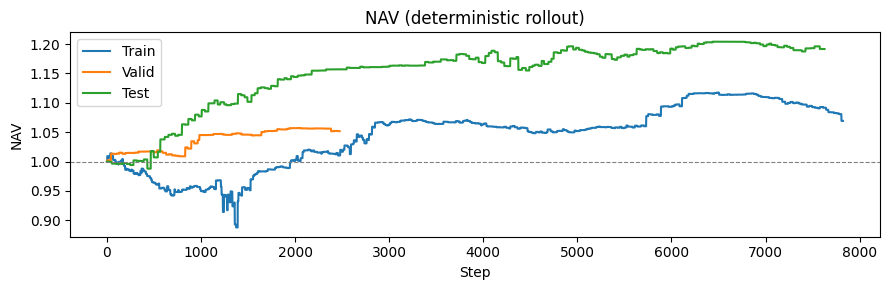

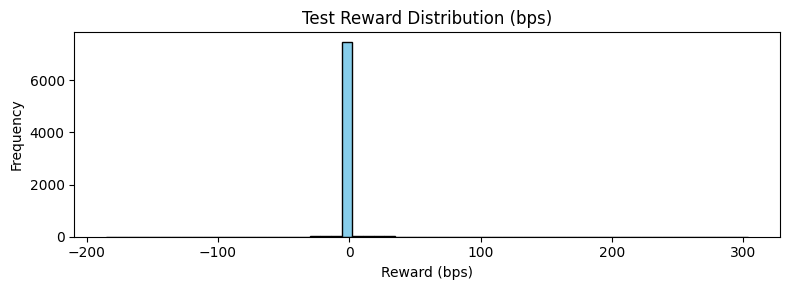

Test turnover (sum |Δpos|): 40.18


In [7]:
import matplotlib.pyplot as plt
import numpy as np
from rl_agent.experiment import deterministic_rewards

def nav_curve(env, policy, label):
    r = deterministic_rewards(env, policy)
    nav = (1 + r / 1e4).cumprod()
    plt.plot(nav, label=label)
    return r, nav

plt.figure(figsize=(9,3))
r_tr, nav_tr = nav_curve(env_tr, net, "Train")
r_va, nav_va = nav_curve(env_va, net, "Valid")
r_te, nav_te = nav_curve(env_te, net, "Test")
plt.axhline(1.0, color="grey", lw=0.8, ls="--")
plt.title("NAV (deterministic rollout)")
plt.xlabel("Step")
plt.ylabel("NAV")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,3))
plt.hist(r_te, bins=60, color="skyblue", edgecolor="k")
plt.title("Test Reward Distribution (bps)")
plt.xlabel("Reward (bps)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

rollout_te = env_te.rollout(lambda obs: net.act(obs, deterministic=True)[0])
positions = rollout_te["positions"]
turnover = np.abs(np.diff(positions)).sum()
print(f"Test turnover (sum |Δpos|): {turnover:.2f}")


In [8]:
def calc_drawdown(nav):
    peak = np.maximum.accumulate(nav)
    dd = nav / peak - 1.0
    return float(dd.min())

summary = []
for split, (env, rewards, nav) in {
    "train": (env_tr, r_tr, nav_tr),
    "valid": (env_va, r_va, nav_va),
    "test":  (env_te, r_te, nav_te),
}.items():
    summary.append({
        "split": split,
        "mean_bps": metrics[split]["mean"] * 1e4,
        "std_bps": metrics[split]["std"] * 1e4,
        "sharpe": metrics[split]["sharpe"],
        "steps": metrics[split]["steps"],
        "max_drawdown": calc_drawdown(nav),
        "turnover": np.abs(np.diff(env.rollout(lambda obs: net.act(obs, deterministic=True)[0])["positions"])).sum()
            if split == "test" else np.nan,
    })

def rollout_stats(env, policy):
    ro = env.rollout(lambda obs: policy.act(obs, deterministic=True)[0])
    nav = (1 + ro["rewards"] / 1e4).cumprod()
    dd = (nav / np.maximum.accumulate(nav) - 1).min()
    turnover = np.abs(np.diff(ro["positions"])).sum()
    return dd, turnover

summary_df = pd.DataFrame(summary).set_index("split")

for split, env in {"train": env_tr, "valid": env_va, "test": env_te}.items():
    dd, turn = rollout_stats(env, net)
    summary_df.loc[split, ["max_drawdown", "turnover"]] = [dd, turn]
summary_df.to_csv(RUN_DIR / "evaluation_summary.csv")

display(summary_df)


,mean_bps,std_bps,sharpe,steps,max_drawdown,turnover
split,,,,,,
train,947.771427,136250.659816,0.110424,7823,-0.124208,69.719727
valid,2057.649864,54906.510322,0.594905,2474,-0.010024,17.008314
test,2331.454830,82276.764054,0.449832,7628,-0.028284,40.178152


In [9]:
## Save results to RUN_DIR

RUN_DIR.mkdir(parents=True, exist_ok=True)

fig_nav = plt.figure(figsize=(9,3))
  # build NAV plot
fig_nav.savefig(RUN_DIR / "nav_curves.png", dpi=150, bbox_inches="tight")

fig_hist = plt.figure(figsize=(8,3))
  # build histogram
fig_hist.savefig(RUN_DIR / "test_reward_hist.png", dpi=150, bbox_inches="tight")

summary_df.to_csv(RUN_DIR / "evaluation_summary.csv", index=True)

np.save(RUN_DIR / "train_rewards.npy", r_tr)
np.save(RUN_DIR / "valid_rewards.npy", r_va)
np.save(RUN_DIR / "test_rewards.npy",  r_te)


<Figure size 900x300 with 0 Axes>

<Figure size 800x300 with 0 Axes>

In [ ]:

from rl_agent.deploy import load_policy

policy_loaded, cfg_loaded, envs_loaded = load_policy(
    run_dir=RUN_DIR,
    panel=panel,
    device="cpu",
)

print("Loaded policy hidden dim:", cfg_loaded["hidden"])
print("Envs keys:", list(envs_loaded.keys()))


In [ ]:

from rl_agent.deploy import load_policy

policy_loaded, cfg_loaded, envs_loaded = load_policy(
    run_dir=RUN_DIR,
    panel=panel,
    device="cpu",
)

print("Loaded policy hidden dim:", cfg_loaded["hidden"])
print("Envs keys:", list(envs_loaded.keys()))
